## Custom SNN LIF neuron Python implementation for electronics engineering bachelor project

In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import copy
import itertools

# Custom neuron implelmentation
from LIF import LIF

# Set random seed for reproducability
np.random.seed(42)

### Simulation Setup

# rSTDP

### Simulation setup

**Parameters for grid search**

In [ ]:
# Architecture parameters
hidden_layers_range = [0]  # Zero for fully connected network
hidden_size_range = [50]   # Not used when hidden_layers=0

# Hyperparameters
beta_range = [0.8, 0.85, 0.90]
threshold_range = [5.0, 7.5, 10.0]
reset_val = 0.0
learning_rate_range = [0.02, 0.05, 0.1]
initial_weight_range = [0.25, 0.5]

# Reward parameters
dopamine_correct_range = [1.0, 2.0, 3.0, 4.0]
dopamine_wrong_range = [-0.2]
dopamine_nofire_range = [-0.05]

# Decay parameters
eligibility_decay_range = [0.90]

# Calculate total combinations
total_combinations = len(list(itertools.product(
    beta_range, threshold_range, learning_rate_range, initial_weight_range,
    dopamine_correct_range, dopamine_wrong_range, dopamine_nofire_range,
    eligibility_decay_range
)))

# Pattern settings
pattern_hold_duration = 100
input_size = 15*15
output_size = 4

results_snn = []
n_runs = 3
time_steps = 2000

for config in tqdm(itertools.product(
    beta_range, threshold_range, learning_rate_range, initial_weight_range,
    dopamine_correct_range, dopamine_wrong_range, dopamine_nofire_range,
    eligibility_decay_range
), total=total_combinations):
    
    (beta, thresh, lr, init_w, d_corr, d_wrng, d_nofi, elig_decay) = config

    run_accuracies = []

    for run in range(n_runs):
        # Initialize network: input → output (no hidden layers)
        input_to_output_synapses = np.random.uniform(init_w-0.1, init_w+0.1, (input_size, output_size))
        
        input_neurons = [LIF(beta=beta, threshold=thresh, learning_rate=lr, reset=reset_val) 
                        for _ in range(input_size)]
        output_neurons = [LIF(beta=beta, threshold=thresh, learning_rate=lr, reset=reset_val) 
                         for _ in range(output_size)]
        
        # Set eligibility decay
        for n in input_neurons + output_neurons:
            n.eligibility_decay = elig_decay
        
        correct_count = 0
        total_spike_events = 0

        # Training Loop
        for t in range(time_steps):
            pattern_idx = (t // pattern_hold_duration) % 10
            input_spikes, correct_output = patterns_2bit[pattern_idx]

            # Update input neurons with raw values (0,1,2,3)
            for i in range(input_size):
                input_neurons[i].update(input_spikes[i])

            # Update output neurons
            current_weights = input_to_output_synapses.copy()
            for j in range(output_size):
                synaptic_input = float(sum(current_weights[i,j] * input_spikes[i] for i in range(input_size)))
                output_neurons[j].update(synaptic_input)

            # Winner-Take-All
            fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
            winner_idx = -1
            if len(fired_indices) > 0:
                winner_idx = np.random.choice(fired_indices)
                total_spike_events += 1
                if winner_idx == correct_output:
                    correct_count += 1
                
                for j in range(output_size):
                    if j != winner_idx:
                        output_neurons[j].spk = 0
                        output_neurons[j].mem = 0

            # Reward
            if winner_idx == correct_output:
                dopamine = d_corr
            elif winner_idx == -1:
                dopamine = d_nofi
            else:
                dopamine = d_wrng

            # R-STDP
            if winner_idx != -1:
                for i in range(input_size):
                    for j in range(output_size):
                        input_to_output_synapses[i,j] = output_neurons[j].rSTDP(
                            input_to_output_synapses[i,j],
                            input_neurons[i].eligibility,
                            is_winner=(j == winner_idx),
                            dopamine=dopamine
                        )

        # Calculate accuracy
        acc = correct_count / total_spike_events if total_spike_events > 0 else 0
        run_accuracies.append(acc)

    # Store Results
    results_snn.append({
        'beta': beta,
        'threshold': thresh,
        'lr': lr,
        'init_weight': init_w,
        'd_correct': d_corr,
        'd_wrong': d_wrng,
        'd_nofire': d_nofi,
        'elig_decay': elig_decay,
        'mean_accuracy': np.mean(run_accuracies),
        'std_accuracy': np.std(run_accuracies)
    })

# Save results
df_results = pd.DataFrame(results_snn)
df_results.to_csv("CSV_results/SNN_ORB_GridSearch_Results.csv", index=False)
print(f"\nBest config: {df_results.loc[df_results['mean_accuracy'].idxmax()]}")

In [ ]:
# Load grid search results
df = pd.read_csv("SNN_GridSearch_Results.csv")

# Top 25 configurations
top_25 = df.sort_values(by=['mean_accuracy', 'std_accuracy'], ascending=[False, True]).head(25)

print("=== Top 25 SNN Configurations ===")
print(top_25[['mean_accuracy', 'std_accuracy', 'beta', 'threshold', 'lr', 
              'init_weight', 'd_correct', 'd_wrong', 'elig_decay']])

# Parameter impact analysis
print("\n=== Impact of Beta on Accuracy ===")
print(df.groupby('beta')['mean_accuracy'].mean())

print("\n=== Impact of Threshold on Accuracy ===")
print(df.groupby('threshold')['mean_accuracy'].mean())

print("\n=== Impact of Learning Rate on Accuracy ===")
print(df.groupby('lr')['mean_accuracy'].mean())

print("\n=== Impact of Initial Weight on Accuracy ===")
print(df.groupby('init_weight')['mean_accuracy'].mean())

print("\n=== Impact of Reward (d_correct) on Accuracy ===")
print(df.groupby('d_correct')['mean_accuracy'].mean())

print("\n=== Impact of Punishment (d_wrong) on Accuracy ===")
print(df.groupby('d_wrong')['mean_accuracy'].mean())

print("\n=== Impact of Eligibility Decay on Accuracy ===")
print(df.groupby('elig_decay')['mean_accuracy'].mean())

# Stable high performers
stable_high = df[(df['mean_accuracy'] > 0.6) & (df['std_accuracy'] < 0.1)]

if not stable_high.empty:
    print("\n=== Most Stable High-Performing Config ===")
    best = stable_high.sort_values(by='mean_accuracy', ascending=False).iloc[0]
    print(best)
else:
    print("\n=== No configs with >60% accuracy and <10% std ===")
    print("Best overall:")
    print(df.sort_values('mean_accuracy', ascending=False).iloc[0])

### **Best parameters**

**rSTDP**

In [ ]:
# Simulation parameters
time_steps = 100
pattern_hold_duration = 10

# Architecture parameter
input_size = 4*3     # Number of input neurons
output_size = 3     # Number of output neurons

# Hyperparameters
beta = 0.80
threshold = 2.5
reset_val = 0.0
learning_rate = 0.1
initial_weight = 0.25

# Reward parameters
dopamine_correct = 3
dopamine_wrong = -0.50
dopamine_nofire = -0.05

# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []


In [ ]:

# Instantiate synapses as a weight matrix, with all weights starting at
input_to_output_synapses = np.full((input_size, output_size), 0.1)
#input_to_output_synapses = np.random.rand(input_size, output_size)
print(f"Sucessfully created synapse matrix {input_to_output_synapses.shape}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


In [ ]:
for t in range(time_steps):
    pattern_idx = (t // pattern_hold_duration) % 10
    input_spikes, correct_output = patterns_2bit[pattern_idx]

    # Update input neurons with raw values (0,1,2,3)
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    current_weights = input_to_output_synapses.copy()

    # Update output neurons - use raw input values, not spikes
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_spikes[i] for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # Winner-take-all
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0

    # Reward
    if winner_idx == correct_output:
        dopamine = dopamine_correct
    elif winner_idx == -1:
        dopamine = dopamine_nofire
    else:
        dopamine = dopamine_wrong

    # R-STDP
    if winner_idx != -1:
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].rSTDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx),
                    dopamine=dopamine
                )

    # Record state
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])
    target_hist.append(correct_output)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_neuron_dynamics(mem_history, threshold_history, spike_history, target_history):
    time_steps = len(mem_history)
    num_neurons = 4  # Specifically set for your 4-pattern simulation
    
    # Create 4 subplots (one for each neuron)
    fig, axes = plt.subplots(num_neurons, 1, figsize=(15, 12), sharex=True)
    
    # Color palette for 4 distinct neurons
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    
    for i in range(num_neurons):
        # Extract individual neuron data
        mems = [m[i] for m in mem_history]
        threshs = [t[i] for t in threshold_history]
        spks = [s[i] for s in spike_history]
        
        # 1. Plot Membrane Potential
        axes[i].plot(mems, label=f'Neuron {i} mem-pot', color=colors[i], alpha=0.8)
        
        # 2. Plot Dynamic Threshold
        axes[i].step(range(time_steps), threshs, label='Threshold', color='black', 
                     linestyle='--', alpha=0.5, where='post')
        
        # 3. Plot Spikes (Red 'x')
        spike_times = [t for t, s in enumerate(spks) if s > 0]
        if spike_times:
            # We plot the 'x' at the threshold level at that time
            axes[i].scatter(spike_times, [threshs[t] for t in spike_times], 
                            color='red', marker='x', s=50, label='Spikes', zorder=5)
        
        # 4. Highlight the "Target" period for this specific neuron
        # We only shade green if target_history[t] matches this neuron's index
        for t in range(time_steps):
            if target_history[t] == i:
                axes[i].axvspan(t, t+1, color='green', alpha=0.08)
        
        # Formatting
        axes[i].set_title(f"Output Neuron {i} Activity")
        axes[i].set_ylabel("Voltage")
        axes[i].legend(loc='upper right', fontsize='small')
        axes[i].grid(True, which='both', linestyle=':', alpha=0.5)

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist, target_hist)


# Add after your loop
correct_count = 0
total_count = 0

for t in range(len(spike_hist)):
    if any(spike_hist[t]):  # If any neuron fired
        winner = np.argmax(spike_hist[t])
        if winner == target_hist[t]:
            correct_count += 1
        total_count += 1

accuracy = 100 * correct_count / total_count if total_count > 0 else 0
print(f"\nFinal Accuracy: {accuracy:.1f}%")
print(f"Correct: {correct_count}/{total_count}")

**STDP**

In [51]:
# Simulation parameters
time_steps = 200
pattern_hold_duration = 10

# Architecture parameter
input_size = 4*3     # Number of input neurons
output_size = 3     # Number of output neurons

# Hyperparameters
beta = 0.95
threshold = 3
reset_val = 0.0
learning_rate = 0.05

# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []

In [52]:
# Input data
spiketrains = pd.read_csv("ORB_test_spiketrains.csv")
for spikes in spiketrains.values:
    print(spikes)

[0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 1 0 0 0 0 1 1 0 1 0]
[0 0 1 0 0 0 0 0 1 0 1 0]
[0 0 0 1 0 0 0 0 0 0 1 0]
[0 0 1 1 0 0 0 0 0 0 1 0]
[0 0 1 0 0 1 0 0 0 0 1 0]
[1 0 0 0 0 1 0 0 0 0 0 0]
[0 0 1 0 1 0 0 0 0 0 1 0]
[0 0 0 0 1 0 0 1 0 1 1 0]
[0 0 0 0 0 1 0 1 0 1 1 0]
[0 0 1 0 0 0 0 1 0 0 0 0]
[0 0 0 1 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 1 0 1 0 0 0]
[0 1 0 0 0 0 1 1 0 0 1 0]
[0 1 1 0 0 1 1 0 0 1 1 0]
[0 1 0 1 0 1 0 0 1 0 1 0]
[0 0 0 0 0 0 0 0 0 1 0 0]
[0 1 0 0 0 0 0 0 0 0 0 0]
[0 1 0 0 0 1 0 0 0 0 0 0]
[0 1 0 0 0 1 1 1 0 0 0 0]
[0 1 0 0 0 0 1 1 1 0 0 1]
[0 0 0 0 0 1 0 1 0 0 0 0]
[0 1 0 1 0 0 1 0 1 0 0 0]
[1 0 1 0 1 0 1 0 1 0 0 1]
[1 0 1 1 1 0 1 0 0 0 0 1]
[1 0 1 0 0 0 1 0 0 0 0 0]
[0 0 0 0 0 1 0 0 0 0 1 0]
[1 1 0 1 1 1 0 0 1 1 0 1]
[0 0 0 0 0 1 1 0 0 0 1 0]
[0 0 0 0 1 0 0 0 0 0 1 0]
[0 0 0 0 1 1 0 0 0 0 0 0]
[0 0 0 0 1 0 0 0 1 0 0 0]
[0 0 0 0 0 0 0 0 0 1 0 1]
[0 0 0 0 0 0 0 1 0 0 0 0]
[0 0 0 0 0 1 0 0 0 0 0 0]
[0 0 0 0 0 0 0 1 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 0]
[0 1 0 0 0 1 0 0 0 0 1 0]
[0 1 0 0 1 0

In [53]:

# Instantiate synapses as a weight matrix, with all weights starting at
#input_to_output_synapses = np.full((input_size, output_size), 0.1)
input_to_output_synapses = np.random.rand(input_size, output_size)
print(f"Sucessfully created synapse matrix {input_to_output_synapses.shape}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


Sucessfully created synapse matrix (12, 3)
Sucessfully created input layer with 12
Sucessfully created output layer with 3


In [54]:
for t in range(time_steps):
    pattern_idx = (t // pattern_hold_duration) % 10
    input_spikes = spiketrains.values[pattern_idx]

    # Update input neurons with raw values
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    current_weights = input_to_output_synapses.copy()

    # Update output neurons - use raw input values
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_spikes[i] for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # Winner-take-all
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0

    # STDP (no reward signal)
    if winner_idx != -1:
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].STDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx)
                )

    # Record state
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])

In [55]:
def plot_neuron_dynamics(mem_history, threshold_history, spike_history):
    time_steps = len(mem_history)
    num_neurons = output_size
    
    # Create 4 subplots (one for each neuron)
    fig, axes = plt.subplots(num_neurons, 1, figsize=(15, 12), sharex=True)
    
    # Color palette for 4 distinct neurons
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
    
    for i in range(num_neurons):
        # Extract individual neuron data
        mems = [m[i] for m in mem_history]
        threshs = [t[i] for t in threshold_history]
        spks = [s[i] for s in spike_history]
        
        # 1. Plot Membrane Potential
        axes[i].plot(mems, label=f'Neuron {i} mem-pot', color=colors[i], alpha=0.8)
        
        # 2. Plot Dynamic Threshold
        axes[i].step(range(time_steps), threshs, label='Threshold', color='black', 
                     linestyle='--', alpha=0.5, where='post')
        
        # 3. Plot Spikes (Red 'x')
        spike_times = [t for t, s in enumerate(spks) if s > 0]
        if spike_times:
            # We plot the 'x' at the threshold level at that time
            axes[i].scatter(spike_times, [threshs[t] for t in spike_times], 
                            color='red', marker='x', s=50, label='Spikes', zorder=5)
        
        
        # Formatting
        axes[i].set_title(f"Output Neuron {i} Activity")
        axes[i].set_ylabel("Voltage")
        axes[i].legend(loc='upper right', fontsize='small')
        axes[i].grid(True, which='both', linestyle=':', alpha=0.5)

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

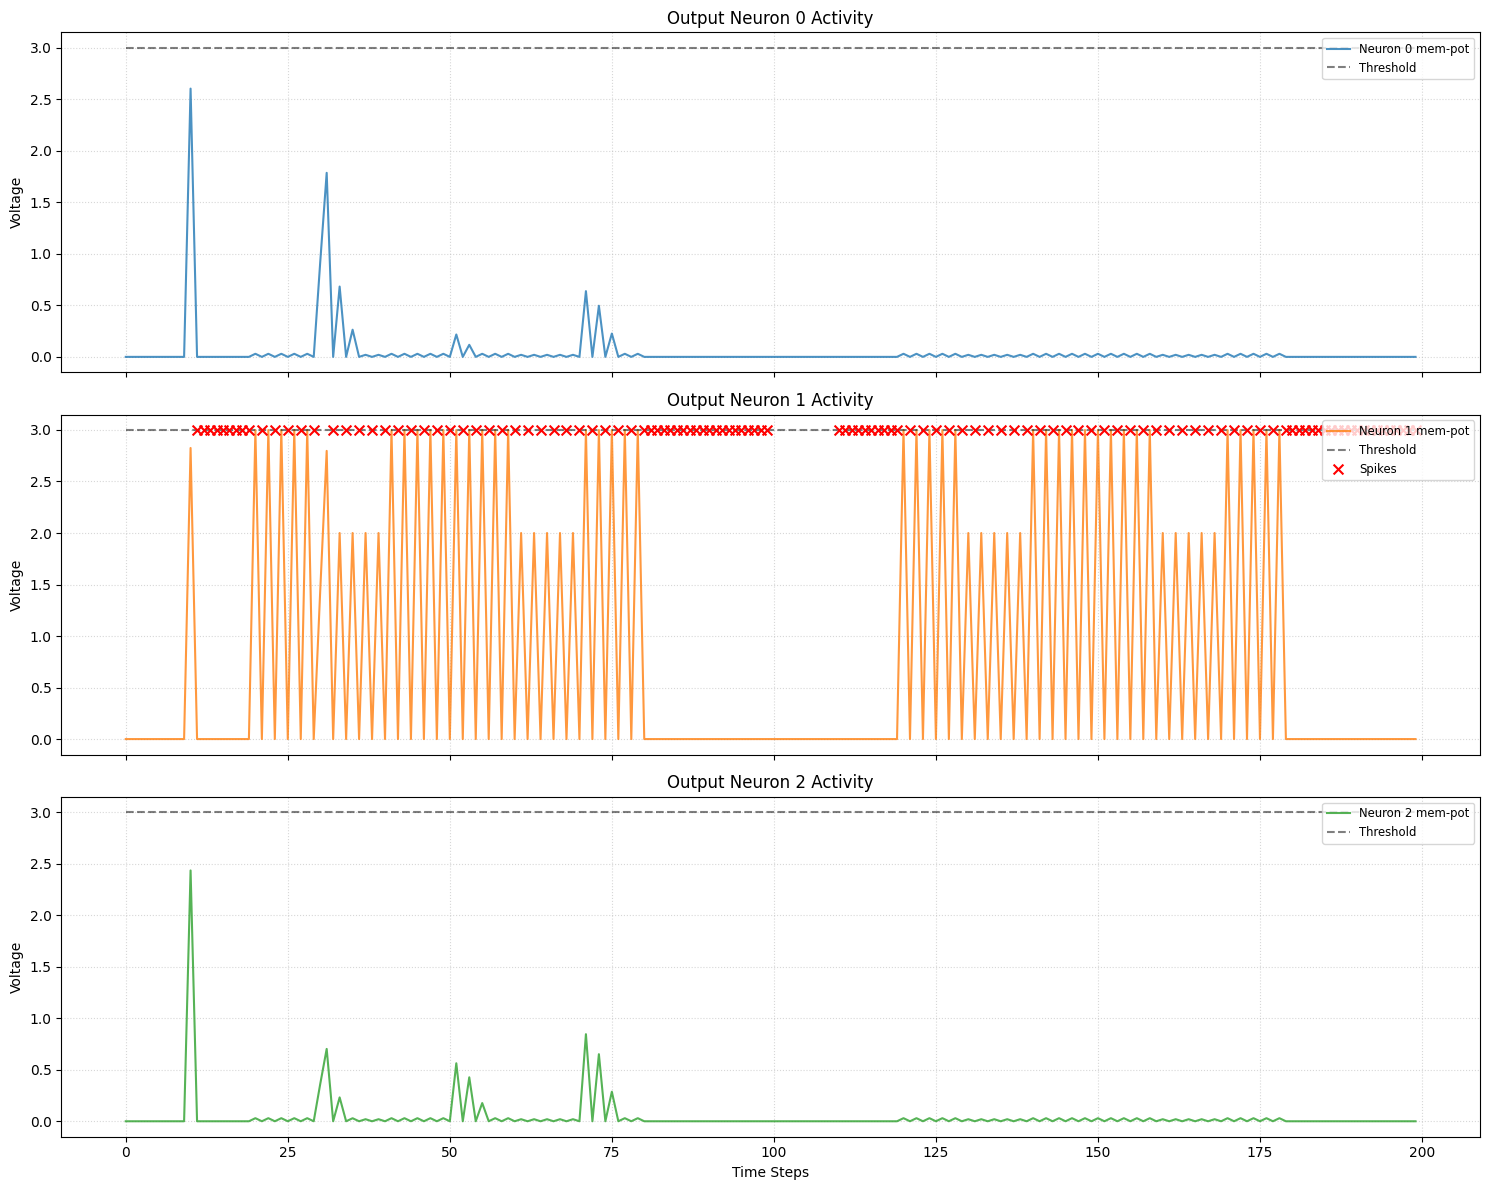

In [56]:
# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist)

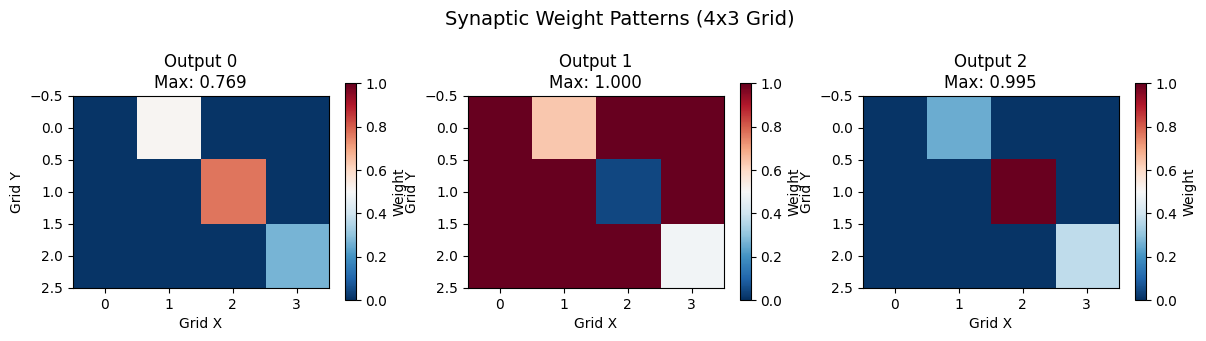

Weight min/max: 0.0100 / 1.0000


In [57]:
import matplotlib.pyplot as plt
import numpy as np

def plot_output_weight_grids(input_to_output_synapses, figsize=(12, 3)):
    """
    Plot weight heatmap for each output neuron as a 2D grid.
    Assumes inputs represent a flattened occupancy grid.
    
    Parameters:
    -----------
    input_to_output_synapses : numpy.ndarray
        Weight matrix of shape (input_size, output_size)
    grid_size : int
        Size of the square grid (default 15 for 15×15 = 225 inputs)
    """
    n_outputs = input_to_output_synapses.shape[1]
    
    fig, axes = plt.subplots(1, n_outputs, figsize=figsize)
    if n_outputs == 1:
        axes = [axes]
    
    for j, ax in enumerate(axes):
        weights = input_to_output_synapses[:, j]
        
        # Reshape to 2D grid
        weight_grid = weights.reshape(3, 4)
        
        im = ax.imshow(weight_grid, cmap='RdBu_r', vmin=0, vmax=1.0)
        ax.set_title(f'Output {j}\nMax: {weights.max():.3f}')
        ax.set_xlabel('Grid X')
        ax.set_ylabel('Grid Y')
        plt.colorbar(im, ax=ax, label='Weight')
        
        # Add grid lines
        ax.grid(False)
    
    plt.suptitle('Synaptic Weight Patterns (4x3 Grid)', fontsize=14, y=1.05)
    plt.tight_layout()
    return fig



# Use the grid visualization:
fig1 = plot_output_weight_grids(input_to_output_synapses)


plt.show()

print(f"Weight min/max: {input_to_output_synapses.min():.4f} / {input_to_output_synapses.max():.4f}")